TASK 2 - DEEP LEARNING
TensorFlow Version: 2.20.0

Dataset shape: (569, 30)
Number of features: 30
Number of samples: 569
Classes: ['malignant' 'benign']

Training samples: 455
Testing samples: 114

Feature scaling completed.

Model compiled successfully.

Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)


TRAINING MODEL
Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.7390 - loss: 0.5916 - val_accuracy: 0.8681 - val_loss: 0.4684
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8929 - loss: 0.3963 - val_accuracy: 0.9011 - val_loss: 0.3167
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9148 - loss: 0.2686 - val_accuracy: 0.9560 - val_loss: 0.2237
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9341 - loss: 0.2018 - val_accuracy: 0.9560 - val_loss: 0.1677
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9396 - loss: 0.1584 - val_accuracy: 0.9560 - val_loss: 0.1336
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9643 - loss: 0.1307 - val_accuracy: 0.9780 - val_loss: 0.1077
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9615 - loss: 0.1176 - val_accuracy: 0.9780 - val_loss: 0.0916
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9670 - loss: 0.1004 - val_accu

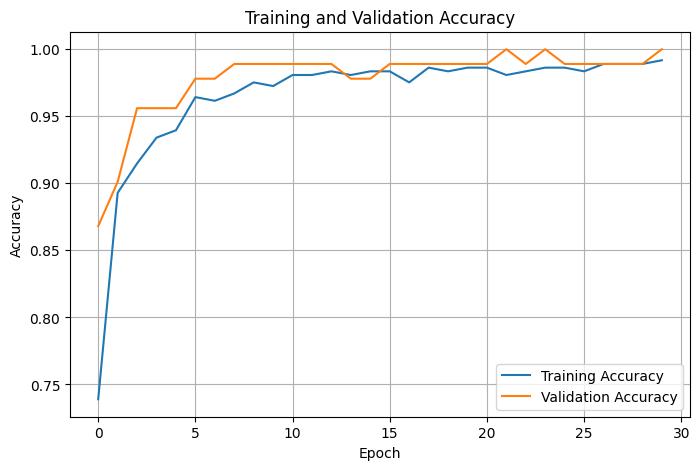

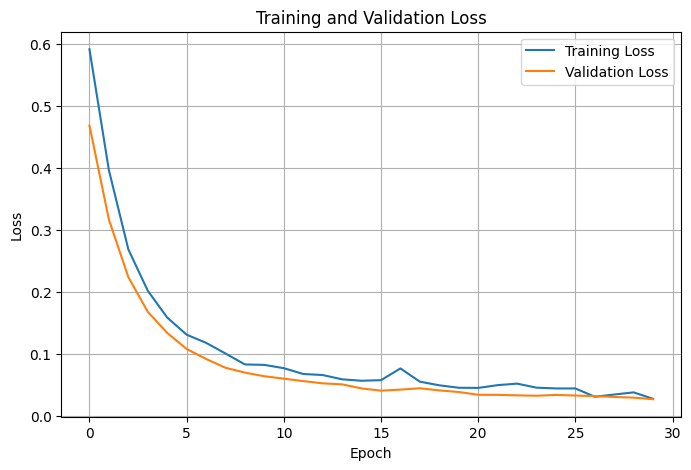


SAMPLE PREDICTION
Predicted Class: malignant
Prediction Probability: 0.0
Actual Class: malignant

Model saved successfully as:
task2_deep_learning_model.keras

TASK 2 COMPLETED SUCCESSFULLY!


In [ ]:
# ============================================================
# TASK 2 - DEEP LEARNING
# Breast Cancer Classification using Neural Network
# ============================================================

# 1. Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("=" * 60)
print("TASK 2 - DEEP LEARNING")
print("=" * 60)

print("TensorFlow Version:", tf.__version__)


# 2. Load dataset
data = load_breast_cancer()

X = data.data
y = data.target

print("\nDataset shape:", X.shape)
print("Number of features:", X.shape[1])
print("Number of samples:", X.shape[0])
print("Classes:", data.target_names)


# 3. Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


# 4. Feature scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nFeature scaling completed.")


# 5. Build Deep Learning model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(30,)),

    tf.keras.layers.Dense(
        64,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(
        32,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(
        16,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])


# 6. Compile model
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("\nModel compiled successfully.")

print("\nModel Architecture:")
model.summary()


# 7. Train model
print("\n" + "=" * 60)
print("TRAINING MODEL")
print("=" * 60)

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


# 8. Evaluate model
print("\n" + "=" * 60)
print("MODEL EVALUATION")
print("=" * 60)

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))
print(
    "Test Accuracy Percentage:",
    round(test_accuracy * 100, 2),
    "%"
)


# 9. Predictions
y_probability = model.predict(
    X_test,
    verbose=0
)

y_pred = (
    y_probability > 0.5
).astype(int).flatten()


# 10. Classification report
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=data.target_names
    )
)


# 11. Confusion matrix
print("\nConfusion Matrix:")

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)


# 12. Plot training and validation accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


# 13. Plot training and validation loss
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


# 14. Sample prediction
sample = X_test[:1]

prediction_probability = model.predict(
    sample,
    verbose=0
)[0][0]

prediction = int(
    prediction_probability > 0.5
)

print("\n" + "=" * 60)
print("SAMPLE PREDICTION")
print("=" * 60)

print(
    "Predicted Class:",
    data.target_names[prediction]
)

print(
    "Prediction Probability:",
    round(float(prediction_probability), 4)
)

print(
    "Actual Class:",
    data.target_names[y_test[0]]
)


# 15. Save model
model.save(
    "task2_deep_learning_model.keras"
)

print("\nModel saved successfully as:")
print("task2_deep_learning_model.keras")

print("\n" + "=" * 60)
print("TASK 2 COMPLETED SUCCESSFULLY!")
print("=" * 60)